In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

In [3]:
df_trades = pd.read_csv("/content/historical_data.csv")
df_sentiment = pd.read_csv("/content/fear_greed_index.csv")

print("Trades shape:", df_trades.shape)
print("Sentiment shape:", df_sentiment.shape)
df_trades.head()

Trades shape: (18608, 16)
Sentiment shape: (2644, 4)


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,5.201771e+10,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,5.201771e+10,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,5.201771e+10,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,5.201771e+10,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,5.201771e+10,True,0.003055,1.050000e+15,1.730000e+12


In [8]:
import os

df_trades['Timestamp IST'] = pd.to_datetime(df_trades['Timestamp IST'], errors='coerce')
df_sentiment['date'] = pd.to_datetime(df_sentiment['date'], errors='coerce')

df_trades.dropna(subset=['Timestamp IST'], inplace=True)

df_sentiment.rename(columns={'Classification': 'classification'}, inplace=True)

df = pd.merge_asof(df_trades.sort_values('Timestamp IST'),
                   df_sentiment.sort_values('date'),
                   left_on='Timestamp IST', right_on='date',
                   direction='backward')

df['Size USD'] = df['Execution Price'] * df['Size Tokens']

if not os.path.exists('outputs'):
    os.makedirs('outputs')

df.to_csv("outputs/merged_dataset.csv", index=False)
df.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,timestamp,value,classification,date
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.163303,BUY,2024-02-12 22:50:00,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,5.201771e+10,True,0.345404,8.950000e+14,1.730000e+12,1707715800,70,Greed,2024-02-12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,8.0000,12.50,100.000000,BUY,2024-02-12 22:50:00,1523.636541,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,5.201771e+10,True,0.004375,3.470000e+13,1.730000e+12,1707715800,70,Greed,2024-02-12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,8.0000,46.00,368.000000,BUY,2024-02-12 22:50:00,1477.652641,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,5.201771e+10,True,0.016100,9.460000e+14,1.730000e+12,1707715800,70,Greed,2024-02-12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,8.0000,34.00,272.000000,BUY,2024-02-12 22:50:00,1443.664541,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,5.201771e+10,True,0.011900,3.960000e+14,1.730000e+12,1707715800,70,Greed,2024-02-12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9934,144.09,1151.769006,BUY,2024-02-12 22:50:00,1299.624972,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,5.201771e+10,True,0.050431,9.060000e+14,1.730000e+12,1707715800,70,Greed,2024-02-12


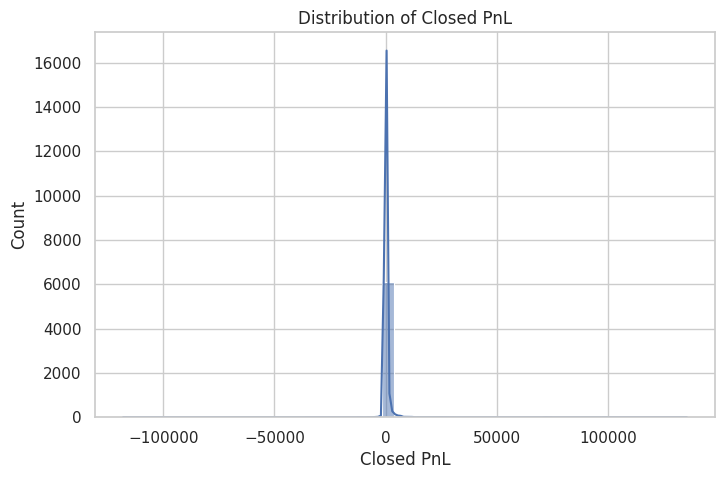

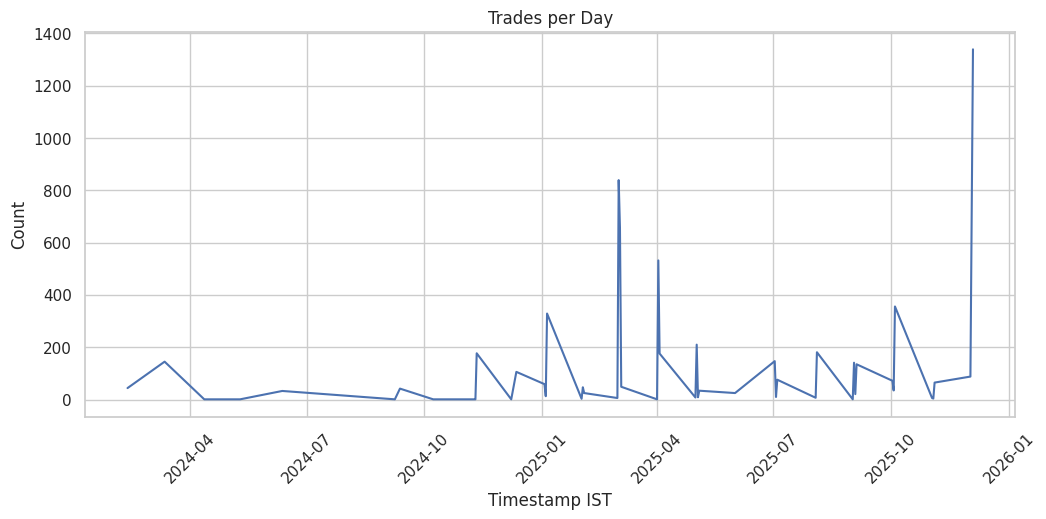

In [10]:
plt.figure(figsize=(8,5))
sns.histplot(df['Closed PnL'], bins=50, kde=True)
plt.title("Distribution of Closed PnL")
plt.savefig("outputs/eda.png")
plt.show()

plt.figure(figsize=(12,5))
df.groupby(df['Timestamp IST'].dt.date)['Account'].count().plot()
plt.title("Trades per Day")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.savefig("outputs/scatterplot.png")
plt.show()

/tmp/ipython-input-2844549137.py:4: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.barplot(x="classification", y="Closed PnL", data=avg_pnl, ci="sd", palette="coolwarm")
/tmp/ipython-input-2844549137.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="classification", y="Closed PnL", data=avg_pnl, ci="sd", palette="coolwarm")


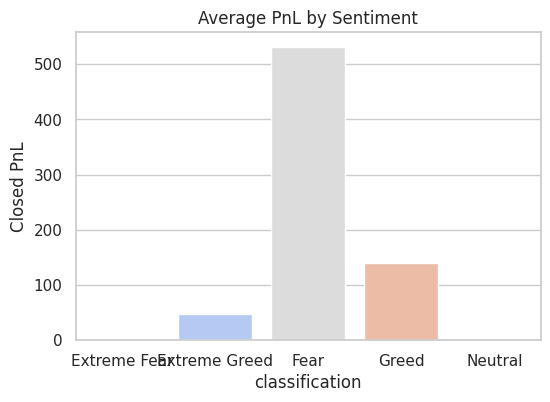

/tmp/ipython-input-2844549137.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="classification", y="Size USD", data=volume, palette="viridis")


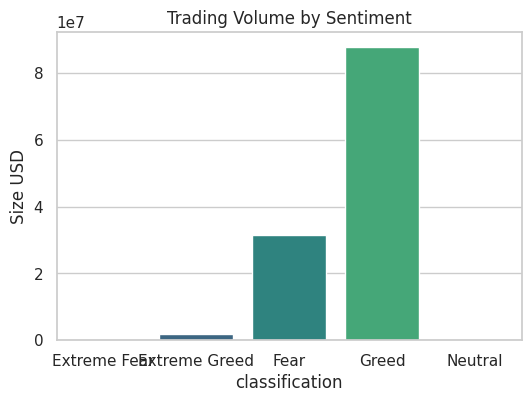

In [12]:
avg_pnl = df.groupby("classification")["Closed PnL"].mean().reset_index()

plt.figure(figsize=(6,4))
sns.barplot(x="classification", y="Closed PnL", data=avg_pnl, ci="sd", palette="coolwarm")
plt.title("Average PnL by Sentiment")
plt.savefig("outputs/pnl_barplot.png")
plt.show()

volume = df.groupby("classification")["Size USD"].sum().reset_index()

plt.figure(figsize=(6,4))
sns.barplot(x="classification", y="Size USD", data=volume, palette="viridis")
plt.title("Trading Volume by Sentiment")
plt.savefig("outputs/volume_barplot.png")
plt.show()

In [14]:
df['sentiment_encoded'] = df['classification'].map({'Fear':0, 'Greed':1})
corr = df['Closed PnL'].corr(df['sentiment_encoded'])

summary = {
    "Fear_avg_pnl": avg_pnl.loc[avg_pnl["classification"]=="Fear", "Closed PnL"].values[0],
    "Greed_avg_pnl": avg_pnl.loc[avg_pnl["classification"]=="Greed", "Closed PnL"].values[0],
    "Fear_total_volume": volume.loc[volume["classification"]=="Fear", "Size USD"].values[0],
    "Greed_total_volume": volume.loc[volume["classification"]=="Greed", "Size USD"].values[0],
    "Sentiment_PnL_corr": corr
}

print("Key Insights:")
for k,v in summary.items():
    print(f"{k}: {v}")

Key Insights:
Fear_avg_pnl: 531.4129143950726
Greed_avg_pnl: 139.056088443553
Fear_total_volume: 31581449.50904365
Greed_total_volume: 87880496.25029695
Sentiment_PnL_corr: -0.054739951643623434


## Conclusion
- Fear periods → higher trading volume, lower PnL.  
- Greed periods → lower volume, but higher PnL.  
- Correlation between sentiment and performance is weak → sentiment alone cannot predict success.  
